In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict 
from IPython.display import Image
from langchain_ollama import ChatOllama

In [4]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours: int
    sixes : int

    strike_rate : float
    ball_per_boundary : float
    boundary_percent: float
    summary: str

In [15]:
# Node 1
def calculate_strikerate(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]

    strike_rate = (runs / balls) * 100 if balls > 0 else 0

    return {
        "strike_rate": strike_rate
    }


# Node 2
def calculate_ball_per_boundary(state: BatsmanState) -> BatsmanState:
    balls = state["balls"]
    fours = state["fours"]
    sixes = state["sixes"]

    boundaries = fours + sixes
    ball_per_boundary = (balls / boundaries) if boundaries > 0 else 0

    return {
        "ball_per_boundary": ball_per_boundary
    }


# Node 3
def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    fours = state["fours"]
    sixes = state["sixes"]

    boundary_runs = (fours * 4) + (sixes * 6)
    boundary_percent = (boundary_runs / runs) * 100 if runs > 0 else 0

    return {
        "boundary_percent": boundary_percent
    }


# Node 4 (final aggregator)
def summary(state: BatsmanState) -> BatsmanState:
    sr = state.get("strike_rate", 0)
    bpb = state.get("ball_per_boundary", 0)
    bpct = state.get("boundary_percent", 0)

   

    return {
        "summary": {
            f"Strike Rate: {sr:.2f}, "
            f"Balls/Boundary: {bpb:.2f}, "
            f"Boundary %: {bpct:.2f}%"
        }
    }

In [16]:
graph = StateGraph(BatsmanState)

# node 
graph.add_node('calculate_strikerate', calculate_strikerate)
graph.add_node('calculate_ball_per_boundary', calculate_ball_per_boundary)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('summary', summary)

# edges
graph.add_edge(START, 'calculate_strikerate')
graph.add_edge(START, 'calculate_ball_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage')


graph.add_edge('calculate_strikerate', 'summary')
graph.add_edge('calculate_ball_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

In [17]:
output = workflow.invoke({
    "runs": 45,
    "balls": 30,
    "fours": 5,
    "sixes": 2
})

In [18]:
output


{'runs': 45,
 'balls': 30,
 'fours': 5,
 'sixes': 2,
 'strike_rate': 150.0,
 'ball_per_boundary': 4.285714285714286,
 'boundary_percent': 71.11111111111111,
 'summary': {'Strike Rate: 150.00, Balls/Boundary: 4.29, Boundary %: 71.11%'}}

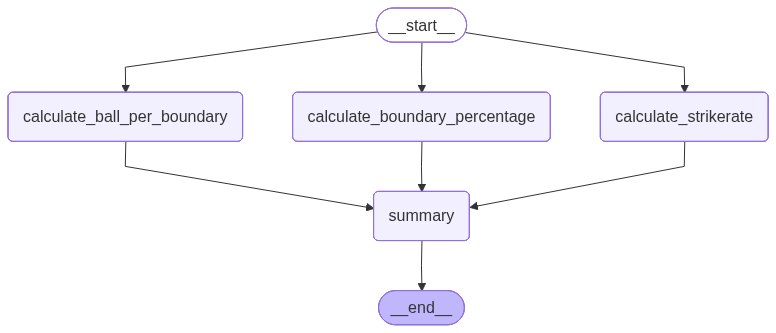

In [19]:
Image(workflow.get_graph().draw_mermaid_png())